In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# load rho-10kb file
data = pd.read_csv("concat_Csec_geq1000_rmind_hardfilt_exhet_biall_dp_qfilt_mac2_maxmiss06_phimp_LDhat_bpen1_statres_filtMQ70depth2stdev.txt_w10kb", sep='\t')
data = data.sort_values(by=['Scaffold', 'Start_bp'])

In [6]:
gff = pd.read_csv('GCF_002891405.2_Csec_1.0_genomic_with_introns.gff', sep='\t', comment='#', header=None)
gff.columns = ['scaffold', 'origin','type', 'start', 'end', 'no_idea', 'strand', 'no_idea2', 'IDstring']

In [7]:
sc = pd.read_csv('GCF_002891405.2_Csec_1.0_assembly_report.txt', sep='\t', comment='#', header=None)
scdict = {k[6]:k[4] for i,k in sc.iterrows()}

In [8]:
gff['scaffold_alt'] = [scdict[i] for i in gff.scaffold]

In [9]:
gff_gene_only = gff.loc[gff.type=='gene']
gff_gene_only['GID'] = [i.split(';')[0].split('=')[1] for i in gff_gene_only.IDstring]

/tmp/ipykernel_3598203/41267217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_gene_only['GID'] = [i.split(';')[0].split('=')[1] for i in gff_gene_only.IDstring]


In [12]:
gff_gene_only

,scaffold,origin,type,start,end,no_idea,strand,no_idea2,IDstring,scaffold_alt,GID
1,NW_019718022.1,Gnomon,gene,753,65939,.,-,.,ID=gene-LOC111862762;Dbxref=GeneID:111862762;N...,NEVH01000001.1,gene-LOC111862762
55,NW_019718022.1,Gnomon,gene,70697,80806,.,+,.,ID=gene-LOC111861660;Dbxref=GeneID:111861660;N...,NEVH01000001.1,gene-LOC111861660
90,NW_019718022.1,Gnomon,gene,173878,348514,.,+,.,ID=gene-LOC111861210;Dbxref=GeneID:111861210;N...,NEVH01000001.1,gene-LOC111861210
150,NW_019718022.1,Gnomon,gene,351201,355080,.,-,.,ID=gene-LOC111875600;Dbxref=GeneID:111875600;N...,NEVH01000001.1,gene-LOC111875600
157,NW_019718022.1,Gnomon,gene,356240,476334,.,+,.,ID=gene-LOC111867727;Dbxref=GeneID:111867727;N...,NEVH01000001.1,gene-LOC111867727
...,...,...,...,...,...,...,...,...,...,...,...
965976,NW_019773482.1,Gnomon,gene,5,871,.,-,.,ID=gene-LOC111875227;Dbxref=GeneID:111875227;N...,NEVH01055461.1,gene-LOC111875227
965987,NW_019773486.1,Gnomon,gene,188,844,.,+,.,ID=gene-LOC111875228;Dbxref=GeneID:111875228;N...,NEVH01055465.1,gene-LOC111875228
966009,NW_019773503.1,Gnomon,gene,44,1142,.,+,.,ID=gene-LOC111875229;Dbxref=GeneID:111875229;N...,NEVH01055482.1,gene-LOC111875229
966016,NW_019773506.1,Gnomon,gene,7,943,.,+,.,ID=gene-LOC117283165;Dbxref=GeneID:117283165;N...,NEVH01055485.1,gene-LOC117283165


In [19]:
def get_gene_density(gff3, rho, winsize=10_000):
    
    win_dict = {}
    win_size = winsize
    for i, te in gff3.iterrows():
        
        # check bin TE is starting in:
        bin_id = np.floor((te.start/win_size))
        bin_bottom= bin_id*win_size
        bin_top = (bin_id+1)*win_size
        win_dict.setdefault(te.scaffold_alt, {}).setdefault(bin_id, {"counter":0,'type':[],"frac":0, "lens":[] })
        win_dict[te.scaffold_alt][bin_id]["counter"] +=1
        win_dict[te.scaffold_alt][bin_id]["type"].append(te["type"])
        
        frac = (np.min([bin_top,te.end]) - np.max([bin_bottom, te.start]))
        win_dict[te.scaffold_alt][bin_id]["lens"].append(frac)
        win_dict[te.scaffold_alt][bin_id]["frac"] += frac
        while te.end>(bin_top*win_size):
            bin_id = bin_id+1
            bin_bottom= bin_id*win_size
            bin_top = (bin_id+1)*win_size
            win_dict.setdefault(te.scaffold_alt, {}).setdefault(bin_id, {"counter":0,'type':[],"frac":0, "lens":[] })
            win_dict[te.scaffold_alt][bin_id]["counter"] +=1
            win_dict[te.scaffold_alt][bin_id]["type"].append(te.type)
            frac = (np.min([bin_top,te.End_pos]) - np.max([bin_bottom, te.start]))
            win_dict[te.scaffold_alt][bin_id]["lens"].append(frac)
            win_dict[te.scaffold_alt][bin_id]["frac"] += frac

    frac_df_all = []
    for scaffold, item in win_dict.items():
        for bin_name, values in item.items():
            line = [scaffold, bin_name*win_size, (bin_name+1)*win_size, values['frac']]
            frac_df_all.append(line)
    frac_df_all = pd.DataFrame(frac_df_all)
    frac_df_all.columns = ["scaffold", 'start_bin', "stop_win", "frac_rep"]
    frac_rho = rho.merge(frac_df_all, left_on=["Scaffold", "Start_bp"], right_on=["scaffold", "start_bin"])
    return win_dict, frac_rho

In [20]:
wd, fr = get_gene_density(gff3=gff_gene_only, rho=data, winsize=10_000)

In [21]:
import scipy as sc

In [33]:
sc.stats.spearmanr(a=fr["Rho_kb"], b=fr["frac_rep"])

SignificanceResult(statistic=-0.018706324767577477, pvalue=0.028145101135719195)

In [39]:
sns.displot

<function seaborn.distributions.displot(data=None, *, x=None, y=None, hue=None, row=None, col=None, weights=None, kind='hist', rug=False, rug_kws=None, log_scale=None, legend=True, palette=None, hue_order=None, hue_norm=None, color=None, col_wrap=None, row_order=None, col_order=None, height=5, aspect=1, facet_kws=None, **kwargs)>

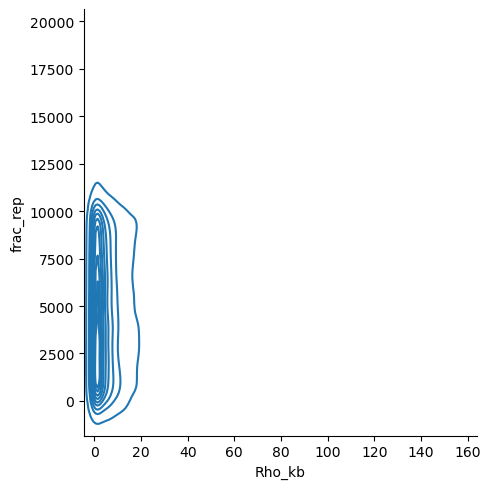

In [23]:
sns.displot(x=fr.Rho_kb, y=fr.frac_rep, kind="kde")

<Axes: xlabel='frac_rep', ylabel='Rho_kb'>

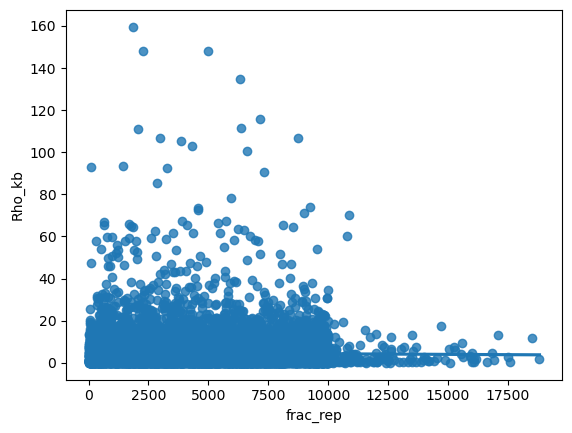

In [25]:
sns.regplot(y=fr.Rho_kb, x=fr.frac_rep)

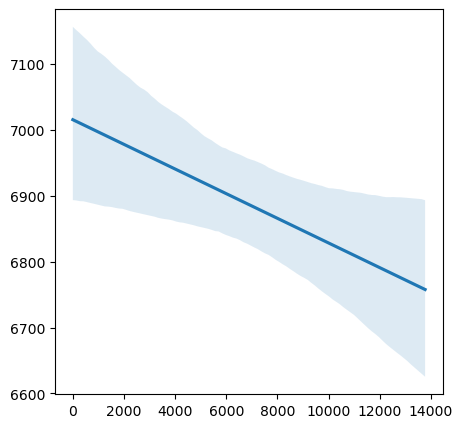

In [27]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5,5))
sns.regplot(y=sc.stats.rankdata(fr.Rho_kb), x=sc.stats.rankdata(fr.frac_rep), scatter=False, scatter_kws={"alpha":0.1}, ax=ax)

#ax.set_xlim(-10,45_000)
#ax.set_ylim(-10,45_000)
plt.show()

array([15044., 10536., 27351., ..., 25546., 14686., 22674.])

In [29]:
import statsmodels.api as sm

In [30]:
rr = sm.formula.ols("Rho_kb ~ frac_rep", data=fr)
rfit= rr.fit()
rfit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Rho_kb   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     6.768
Date:                Thu, 22 Feb 2024   Prob (F-statistic):            0.00929
Time:                        15:23:32   Log-Likelihood:                -47242.
No. Observations:               13772   AIC:                         9.449e+04
Df Residuals:                   13770   BIC:                         9.450e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8257      0.120     40.170      0.000       4.590       5.061
frac_rep   -5.562e-05   2.14e-05     -2.601      0.009   -9.75e-05   -1.37e-05
==============================================================================
Omnibus:                    17312.619   Durbin-Watson:                   1.448
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3893741.838
Skew:                           6.795   Prob(JB):                         0.00
Kurtosis:                      84.245   Cond. No.                     1.06e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.06e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""